In [89]:
%load_ext autoreload
%autoreload 2
import importlib 
hg = importlib.import_module(".model", "src")

m = importlib.import_module(".analytic-intersection-asymptotics", "src")
from matplotlib import pyplot as plt
import numpy as np
from scipy.special import binom
import xgi
import copy 
plt.style.use("seaborn-whitegrid")

from collections import defaultdict, Counter
import matplotlib as mpl
from matplotlib.colors import LinearSegmentedColormap, ListedColormap

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


/var/folders/xn/wvbwvw0d6dx46h9_2bkrknnw0000gn/T/ipykernel_9167/1788881870.py:12: MatplotlibDeprecationWarning: The seaborn styles shipped by Matplotlib are deprecated since 3.6, as they no longer correspond to the styles shipped by seaborn. However, they will remain available as 'seaborn-v0_8-<style>'. Alternatively, directly use the seaborn API instead.
  plt.style.use("seaborn-whitegrid")


### Parameters

In [90]:
k_max = 7
pars = {
    "eta"   : 0.5, 
    "beta"  : np.zeros(k_max),
    "gamma" : np.zeros(k_max)
}

pars["beta"][0:3] = 1/3
pars["gamma"][0:3] = 1/3

eta, beta, gamma = pars["eta"], pars["beta"], pars["gamma"]


### Build some simple simulations for comparison

In [91]:
timesteps = int(1e5)
H = hg.GrowingHypergraph()
H.add_edge((0, 1))
H.add_edge((2, 3))

max_size = 3
# r = np.zeros(shape=(max_size, max_size, max_size))
r = defaultdict(int)
r[(2, 2, 0)] = 1
save_r = []
edge_size_dict = defaultdict(int)
edge_size_dict[2] += 2


In [92]:
update_every = 100

R = np.zeros(shape = (timesteps // update_every, k_max), dtype = int)

# print(R.shape)

for cc in range(timesteps):
    e_ = H.sample_edge(eta, gamma, beta, True)
    eid = H.num_edges-1
    e_size = len(e_)    
    # update the size of r accordingly. it should always be max_size + 1
    # find all neighbors that have intersection with e_
    de = H.edge_neighborhood(eid, prior_only = True, as_node_sets = True)
    # count all the intersection sizes and add to r
    for nb in de:
        nb_size = len(nb)
        k = len(e_.intersection(nb))
        r[(e_size, nb_size, k)] += 1
        if nb_size != e_size:
            r[(nb_size, e_size, k)] += 1
        
    neighbor_sizes = [len(x) for x in de]
    nb_size_cnt = Counter(neighbor_sizes)
    for j, nj in edge_size_dict.items():
        # assert(nj >= nb_size_cnt[j])
        r[(j, e_size, 0)] += nj - nb_size_cnt[j]
        if j != e_size:
            r[(e_size, j, 0)] += nj - nb_size_cnt[j]

    if cc % update_every == 0:
        # print(cc)
        for k in range(k_max):
            R[cc//update_every, k] = sum([r[(i, j, k)] for i in range(k_max) for j in range(k_max)])
    edge_size_dict[e_size] += 1

In [93]:
R

array([[         1,          4,          0, ...,          0,          0,
                 0],
       [      4649,       1999,        433, ...,         18,          0,
                 0],
       [     21321,       5369,        954, ...,         35,          2,
                 0],
       ...,
       [5749525013,   19595582,     397927, ...,      17957,       2085,
                57],
       [5761091677,   19636548,     398352, ...,      17973,       2085,
                57],
       [5773145807,   19660060,     398666, ...,      17993,       2087,
                57]])

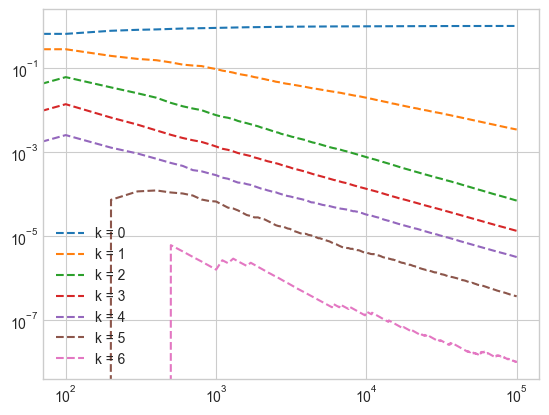

In [94]:
fig, ax = plt.subplots(1, 1)
R = R / R.sum(axis = 1)[:, None]
for k in range(k_max): 
    ax.plot(np.arange(timesteps // update_every)*update_every, R[:, k], label = f"k = {k}", linestyle = "--")



ax.loglog()
ax.legend()

### Linear Algebra Approximation

A components
sparsity = 0.4898, nan = 0.0000
sparsity = 0.9130, nan = 0.0000
sparsity = 0.7347, nan = 0.0000
A
sparsity = 0.8803, nan = 0.0000
B
sparsity = 0.7522, nan = 0.0000


/Users/philchodrow/Desktop/HyperGraph/code/src/analytic-intersection-asymptotics.py:61: RuntimeWarning: invalid value encountered in divide
  # zero out elements where the binomial coefficients are invalid
/Users/philchodrow/Desktop/HyperGraph/code/src/analytic-intersection-asymptotics.py:80: RuntimeWarning: divide by zero encountered in divide
  mask = np.tile(mask, (k_max,  k_max,1, 1, k_max, 1))
/Users/philchodrow/Desktop/HyperGraph/code/src/analytic-intersection-asymptotics.py:80: RuntimeWarning: invalid value encountered in divide
  mask = np.tile(mask, (k_max,  k_max,1, 1, k_max, 1))


[Text(0.5, 1.0, 'Sparsity: 0.930')]

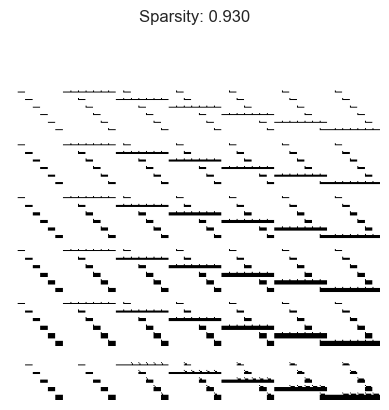

In [131]:
MC = m.MatrixConstructor(k_max, pars)
M = MC.matrix_of_linear_map()
plt.imshow(M > 0, vmin = 0, vmax = 1)
plt.gca().axis("off")
plt.gca().set(title = f"Sparsity: {(M == 0).mean():.3f}")

In [132]:
EV = np.linalg.eig(M)

In [133]:
v = np.abs(EV[1][:,0])
T = m.vec_to_tensor(v, k_max)

q = T.sum(axis = (0, 1))
q = q / q.sum()
np.log(q)

q

array([1.78483326e-17, 2.32873676e-01, 3.22042907e-01, 2.62370071e-01,
       1.35809547e-01, 4.12940323e-02, 5.60976715e-03])

# Sample Asymptotics Plot

Eventually we want these curves to line up with the asymptotic lines, although obviously we are not there yet. 

/var/folders/xn/wvbwvw0d6dx46h9_2bkrknnw0000gn/T/ipykernel_9167/358406055.py:21: RuntimeWarning: divide by zero encountered in divide
  ax.plot(M, q[k]*1/M, label = f"k = {k}", color = cmap(k/k_max))


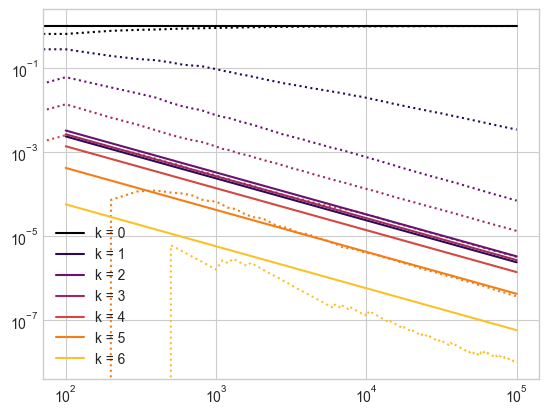

In [135]:

import matplotlib.cm as cm
cmap = cm.inferno

fig, ax = plt.subplots(1, 1)
R = R / R.sum(axis = 1)[:, None]
for k in range(k_max): 
    ax.plot(np.arange(timesteps // update_every)*update_every, R[:, k], linestyle = ":", color = cmap(k/k_max))

q = T.sum(axis = (0, 1))
q = q / q.sum()
np.log(q)

q

M = np.arange(0, 1000)*100 + 0

for k in range(0, len(q)): 
    if k == 0: 
        ax.plot(M, np.ones_like(M), label = f"k = {k}", color = cmap(k/k_max))
    else:    
        ax.plot(M, q[k]*1/M, label = f"k = {k}", color = cmap(k/k_max))

ax.loglog()
plt.legend()


## Diagnostics on A (second terms)


A components
sparsity = 0.4898, nan = 0.0000
sparsity = 0.9130, nan = 0.0000
sparsity = 0.7347, nan = 0.0000
A
sparsity = 0.8803, nan = 0.0000
B
sparsity = 0.7522, nan = 0.0000


/Users/philchodrow/Desktop/HyperGraph/code/src/analytic-intersection-asymptotics.py:61: RuntimeWarning: invalid value encountered in divide
  # zero out elements where the binomial coefficients are invalid
/Users/philchodrow/Desktop/HyperGraph/code/src/analytic-intersection-asymptotics.py:80: RuntimeWarning: divide by zero encountered in divide
  mask = np.tile(mask, (k_max,  k_max,1, 1, k_max, 1))
/Users/philchodrow/Desktop/HyperGraph/code/src/analytic-intersection-asymptotics.py:80: RuntimeWarning: invalid value encountered in divide
  mask = np.tile(mask, (k_max,  k_max,1, 1, k_max, 1))
/var/folders/xn/wvbwvw0d6dx46h9_2bkrknnw0000gn/T/ipykernel_9167/713060407.py:8: RuntimeWarning: divide by zero encountered in log
  plt.imshow(np.log(A))


[Text(0.5, 0, 'intersection size k'),
 Text(0, 0.5, 'New edge size i'),
 Text(0.5, 1.0, 'probability mass = 0.417')]

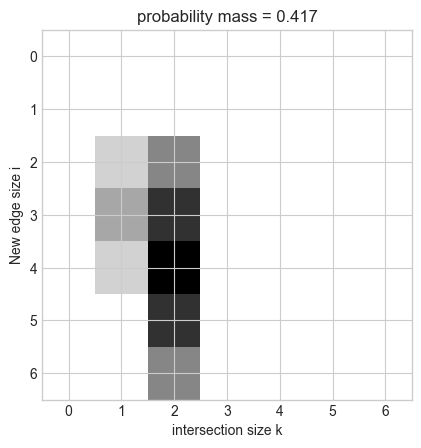

In [125]:
MC = m.MatrixConstructor(k_max, pars)

ell = 3
j   = 2
h   = 3

A = MC.A[:, :, ell, j, h]
plt.imshow(np.log(A))
plt.gca().set(xlabel = "intersection size k", ylabel = "New edge size i", title = f"probability mass = {A.sum():.3f}")


Don't think the above is right. If $\ell = 3$, $j = 2$, and $h = 3$, then it should be p possible here to have $i = 2$ and $k = 1$; we would need to sample exactly one node from $|f \cap g|$ and then add a novel node. So, this case needs to be made possible, and then we need to look for other sources of normalization violations. 

[Text(0.5, 0, 'extra nodes y'), Text(0, 0.5, 'edge size i')]

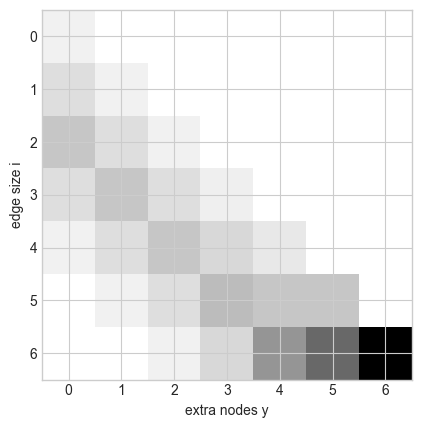

In [139]:
x = 0

MC.S1_iy[:, x, x, x, x, :].sum(axis = 0)
plt.imshow(MC.S1_iy [:,x, x, x, x, :])
plt.gca().set(xlabel = "extra nodes y", ylabel = "edge size i")

S1_iy